In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [28]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [29]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [30]:
 X_train.shape

(60000, 28, 28)

In [31]:
 X_test.shape

(10000, 28, 28)

In [32]:
 y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [33]:
import matplotlib.pyplot as plt


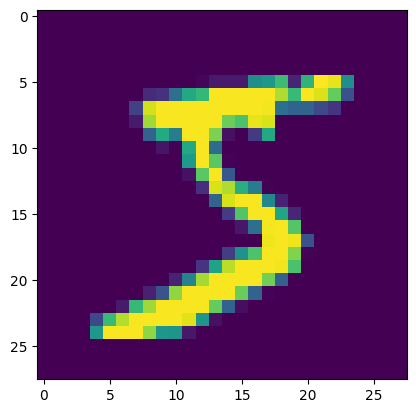

In [34]:
plt.imshow(X_train[0])

In [35]:
X_train = X_train/255
X_test = X_test/255

In [36]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(loss= 'sparse_categorical_crossentropy',optimizer = 'Adam',metrics=['accuracy'])

In [39]:
history = model.fit(X_train,y_train,epochs =10 ,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8658 - loss: 0.4776 - val_accuracy: 0.9548 - val_loss: 0.1575
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9600 - loss: 0.1352 - val_accuracy: 0.9635 - val_loss: 0.1164
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9738 - loss: 0.0897 - val_accuracy: 0.9699 - val_loss: 0.1030
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9799 - loss: 0.0660 - val_accuracy: 0.9722 - val_loss: 0.0905
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9851 - loss: 0.0479 - val_accuracy: 0.9738 - val_loss: 0.0868
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9896 - loss: 0.0356 - val_accuracy: 0.9729 - val_loss: 0.0913
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9916 - loss: 0.0292 - val_accuracy: 0.9762 - val_loss: 0.0878
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9946 - loss: 0.0210 - 

In [40]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [41]:
y_prob

array([[1.03612126e-10, 5.56455299e-11, 1.48998556e-08, ...,
        9.99997318e-01, 5.24632178e-11, 3.03199670e-08],
       [3.71878986e-11, 1.51164087e-07, 9.99999821e-01, ...,
        4.32430437e-17, 5.40150924e-10, 1.80334389e-20],
       [2.99156142e-07, 9.99826908e-01, 5.66914678e-05, ...,
        1.12784819e-05, 8.99231163e-05, 4.39071869e-07],
       ...,
       [1.86485171e-20, 3.47713113e-16, 2.05417586e-16, ...,
        8.50187387e-09, 7.94822402e-11, 5.23885157e-09],
       [2.18546297e-12, 1.27434562e-13, 1.26582747e-14, ...,
        3.30196565e-10, 1.02782891e-04, 3.70240642e-15],
       [1.06177057e-12, 5.15653965e-16, 1.22133664e-10, ...,
        2.29111798e-16, 4.17483687e-11, 1.61705313e-16]], dtype=float32)

In [42]:
y_pred = y_prob.argmax(axis = 1)

In [43]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.977

In [44]:
import matplotlib.pyplot as plt

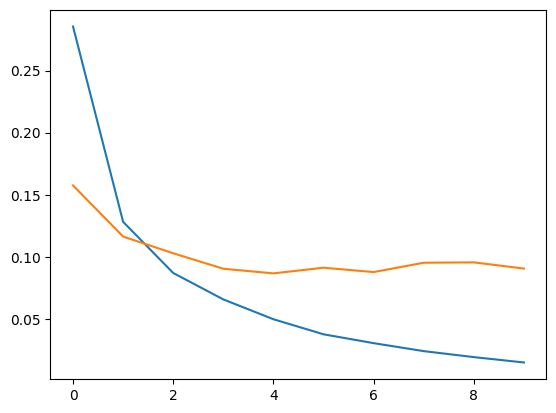

In [46]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

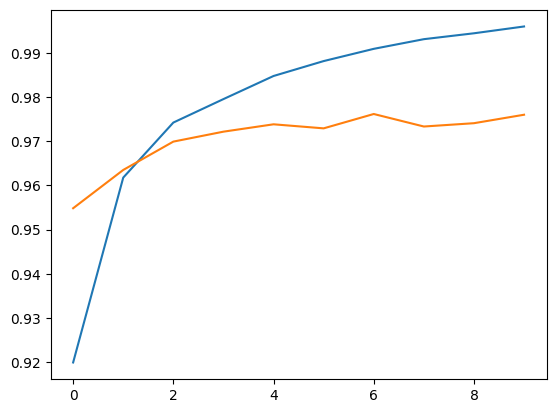

In [47]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

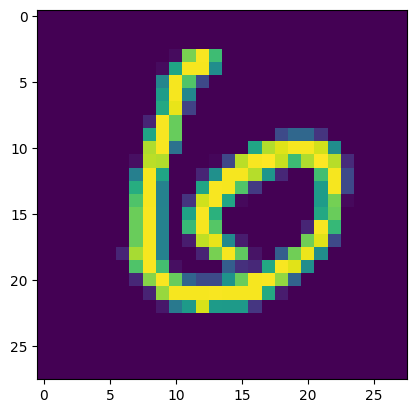

In [67]:
plt.imshow(X_test[11])

In [66]:
model.predict(X_test[11].reshape(1,28,28)).argmax(axis =1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([6])

In [58]:
ypred

array([5])